In [359]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo CSV
csv = pd.read_csv('lista_de_espera_sisu_2022_2.csv', sep='|', encoding='latin-1')

# Filtrar e limpar dados
dados = csv[['UF_CANDIDATO', 'UF_IES', 'QT_VAGAS_CONCORRENCIA', 'NOTA_CANDIDATO', 'TP_COTA']]
dados = dados.dropna(subset=['UF_CANDIDATO', 'UF_IES', 'QT_VAGAS_CONCORRENCIA', 'NOTA_CANDIDATO', 'TP_COTA'])
dados['QT_VAGAS_CONCORRENCIA'] = pd.to_numeric(dados['QT_VAGAS_CONCORRENCIA'], errors='coerce')
dados['NOTA_CANDIDATO'] = pd.to_numeric(dados['NOTA_CANDIDATO'], errors='coerce')



C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1739097620.py:5: DtypeWarning: Columns (22,23,24,25,26,27,28,29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv('lista_de_espera_sisu_2022_2.csv', sep='|', encoding='latin-1')


In [360]:
# Agrupamento dos dados
agrupado_uf_cota = dados.groupby(['UF_CANDIDATO', 'TP_COTA']).agg({
    'QT_VAGAS_CONCORRENCIA': 'sum',
    'NOTA_CANDIDATO': 'mean'
}).reset_index()

total_vagas_uf = dados.groupby('UF_CANDIDATO')['QT_VAGAS_CONCORRENCIA'].sum().reset_index()
media_nota_uf = dados.groupby('UF_CANDIDATO')['NOTA_CANDIDATO'].mean().reset_index()


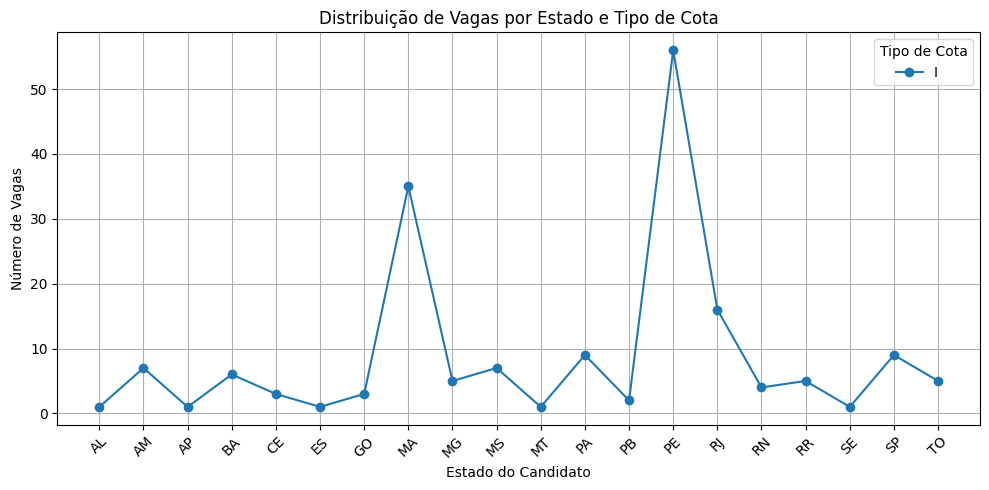

In [361]:
# Gráfico 1

plt.figure(figsize=(10, 5))
for tipo_cota in agrupado_uf_cota['TP_COTA'].unique(): subset = agrupado_uf_cota[agrupado_uf_cota['TP_COTA'] == tipo_cota]
plt.plot(subset['UF_CANDIDATO'], subset['QT_VAGAS_CONCORRENCIA'], marker='o', label=tipo_cota)
    
plt.xticks(rotation=45)
plt.title('Distribuição de Vagas por Estado e Tipo de Cota')
plt.xlabel('Estado do Candidato')
plt.ylabel('Número de Vagas')
plt.legend(title='Tipo de Cota')
plt.grid(True)
plt.tight_layout()
plt.savefig('distribuicao_de_cursos.png')

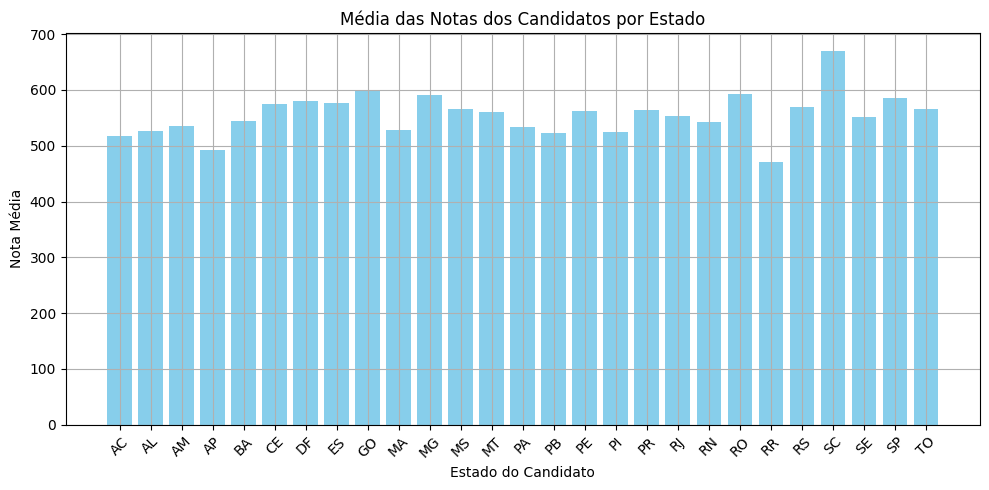

In [362]:
# Gráfico 2

plt.figure(figsize=(10, 5))
plt.bar(media_nota_uf['UF_CANDIDATO'], media_nota_uf['NOTA_CANDIDATO'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Média das Notas dos Candidatos por Estado')
plt.xlabel('Estado do Candidato')
plt.ylabel('Nota Média')
plt.grid(True)
plt.tight_layout()
plt.savefig('media_nota_candidato.png')

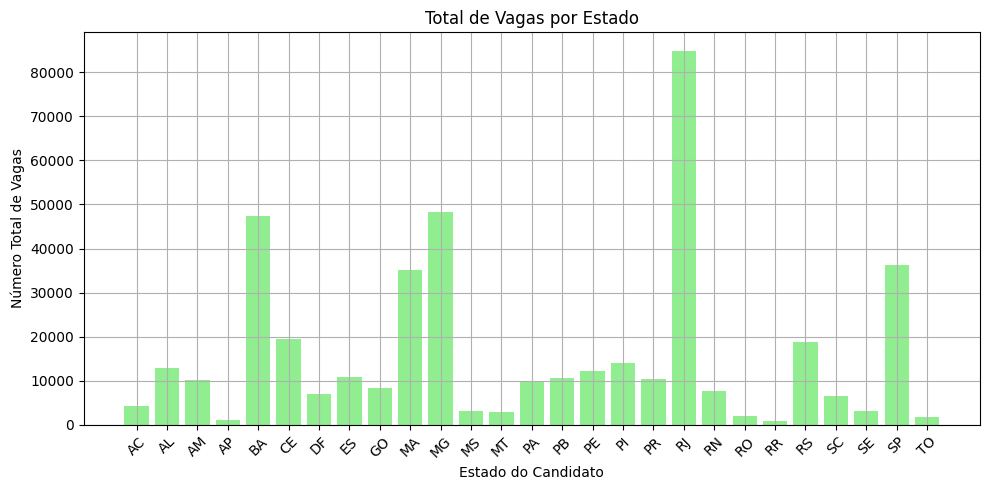

In [363]:
# Gráfico 3

plt.figure(figsize=(10, 5))
plt.bar(total_vagas_uf['UF_CANDIDATO'], total_vagas_uf['QT_VAGAS_CONCORRENCIA'], color='lightgreen')
plt.xticks(rotation=45)
plt.title('Total de Vagas por Estado')
plt.xlabel('Estado do Candidato')
plt.ylabel('Número Total de Vagas')
plt.grid(True)
plt.tight_layout()
plt.savefig('vagas_por_estado.png')

In [364]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

# Título principal
pdf.set_font("times", size=24)
pdf.cell(0, 20, txt="A Jornada #Kick", ln=True, align='C')

# Subtítulo
pdf.set_font("times", size=16)
pdf.cell(0, 10, txt="Curso de Tecnologia", ln=True, align='C')

# Espaçamento entre o subtítulo e o autor
pdf.ln(30)

# Nome do autor
pdf.set_font("times", size=18)
pdf.cell(0, 10, txt="ANDERSON A. DELFINO", ln=True, align='C')

# Espaçamento entre o autor e o Título
pdf.ln(60)

# Título do trabalho
pdf.set_font("times", size=18, style='B')
pdf.cell(0, 10, txt="ANÁLISE DA DESIGUALDADE NA EDUCAÇÃO BRASILEIRA", ln=True, align='C')

# Espaçamento antes de informações adicionais
pdf.ln(110)

# Rodape
pdf.set_font("times", size=12)
pdf.cell(0, 0, txt="SISU 2022", ln=True, align='C')


C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\3391214517.py:8: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(0, 20, txt="A Jornada #Kick", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\3391214517.py:8: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 20, txt="A Jornada #Kick", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\3391214517.py:12: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(0, 10, txt="Curso de Tecnologia", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\3391214517.py:12: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, txt="Curso de Tecnologia", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\3391214517.py:19: DeprecationWar

False

In [365]:
# título
pdf.add_page() 
pdf.set_font("Arial", size=16)
pdf.ln(15)
pdf.cell(200, 10, txt="ANÁLISE DA DESIGUALDADE NA EDUCAÇÃO BRASILEIRA - SISU 2022", ln=True, align='C')

# texto 1
pdf.set_font("Arial", size=12)
pdf.ln(20)
pdf.multi_cell(0, 10, txt= "A desigualdade no acesso ao ensino superior é uma questão crítica no Brasil. O gráfico revela que, ao contrário do esperado, estados como São Paulo podem apresentar um número relativamente baixo de vagas em comparação a outros estados. Isso pode ser resultado de uma alta demanda e concorrência, refletindo a densidade populacional e a grande quantidade de candidatos. Essa realidade sugere que, mesmo em estados com uma infraestrutura de ensino superior mais desenvolvida, o acesso ainda pode ser limitado devido à concorrência intensa.")

# primeiro gráfico

pdf.ln(30)
pdf.image('distribuicao_de_cursos.png', x=10, w=190)

# Espaçamento antes de informações adicionais
pdf.ln(30)

# Rodape
pdf.set_font("times", size=12)
pdf.cell(0, 0, txt="SISU 2022", ln=True, align='C')



C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\873127981.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=16)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\873127981.py:5: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(200, 10, txt="ANÁLISE DA DESIGUALDADE NA EDUCAÇÃO BRASILEIRA - SISU 2022", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\873127981.py:5: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(200, 10, txt="ANÁLISE DA DESIGUALDADE NA EDUCAÇÃO BRASILEIRA - SISU 2022", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\873127981.py:8: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\

False

In [366]:
# texto 2
pdf.add_page() 
pdf.set_font("Arial", size=12)
pdf.ln(10)
pdf.multi_cell(0, 10, txt= "O gráfico seguinte, mostra a média das notas dos candidatos, indicando que estados com maior investimento em educação tendem a ter notas mais altas. Disparidades nas médias refletem desigualdades na qualidade da educação básica, impactando diretamente a preparação dos alunos para o Sisu.")

# segundo gráfico

pdf.ln(35)
pdf.image('media_nota_candidato.png', x=10, w=190)

# Espaçamento antes de informações adicionais
pdf.ln(80)

# Rodape
pdf.set_font("times", size=12)
pdf.cell(0, 0, txt="SISU 2022", ln=True, align='C')


C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\367703484.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\367703484.py:5: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.multi_cell(0, 10, txt= "O gráfico seguinte, mostra a média das notas dos candidatos, indicando que estados com maior investimento em educação tendem a ter notas mais altas. Disparidades nas médias refletem desigualdades na qualidade da educação básica, impactando diretamente a preparação dos alunos para o Sisu.")
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\367703484.py:17: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(0, 0, txt="SISU 2022", ln=True, align='C')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\367703484.py:17: DeprecationWarning: The parameter "ln" is deprecated si

False

In [367]:
# texto 3
pdf.add_page() 
pdf.set_font("Arial", size=12)
pdf.ln(10)
pdf.multi_cell(0, 10, txt= "Já no terceiro e último gráfico, podemos analisar que, mostra o total de vagas por estado ilustra a desigualdade no acesso ao ensino superior. Estados com alta concentração populacional e instituições, como São Paulo e Rio de Janeiro, podem ter um número elevado de candidatos, mas isso não se traduz necessariamente em uma quantidade proporcional de vagas, evidenciando um descompasso entre a demanda e a oferta.")

# terceiro gráfico

pdf.ln(10)
pdf.image('vagas_por_estado.png', x=10, w=190)
pdf.ln(10)


C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1968345829.py:3: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1968345829.py:5: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.multi_cell(0, 10, txt= "Já no terceiro e último gráfico, podemos analisar que, mostra o total de vagas por estado ilustra a desigualdade no acesso ao ensino superior. Estados com alta concentração populacional e instituições, como São Paulo e Rio de Janeiro, podem ter um número elevado de candidatos, mas isso não se traduz necessariamente em uma quantidade proporcional de vagas, evidenciando um descompasso entre a demanda e a oferta.")


In [368]:

# título
pdf.set_font("Arial", size=14)
pdf.cell(200, 10, txt="Conclusão", ln=True, align='L')

# conclusão
pdf.set_font("Arial", size=12)
pdf.ln()
pdf.multi_cell(0, 10, txt= "Depois de ter realizado toda esta análise dos dados do SISU 2022 pode se dizer que temos disparidades significativas no acesso ao ensino superior no Brasil. Embora alguns estados apresentem melhores médias de notas e uma quantidade maior de vagas, a realidade é que muitos estudantes enfrentam barreiras significativas devido à intensa concorrência e à desigualdade educacional. É crucial que políticas públicas sejam implementadas para aumentar a oferta de vagas e melhorar a qualidade da educação básica, especialmente em regiões que historicamente têm menos recursos.")

# Espaçamento antes de informações adicionais
pdf.ln(0)

# Rodape
pdf.set_font("times", size=12)
pdf.cell(0, 0, txt="SISU 2022", ln=True, align='C')

pdf.output("ANÁLISE DA DESIGUALDADE NA EDUCAÇÃO BRASILEIRA - SISU 2022.pdf")

C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1965943216.py:2: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=14)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1965943216.py:3: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(200, 10, txt="Conclusão", ln=True, align='L')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1965943216.py:3: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(200, 10, txt="Conclusão", ln=True, align='L')
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1965943216.py:6: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\Dell\AppData\Local\Temp\ipykernel_3732\1965943216.py:8: DeprecationWarning: The parameter "txt